In [2]:
# Alle Zeilen anzeigen (kein ... mehr)
pd.set_option('display.max_rows', None)

# Alle Spalten anzeigen
pd.set_option('display.max_columns', None)

# Keine Zeilenumbrüche in Zellen (langer Text bleibt lang)
pd.set_option('display.max_colwidth', None)

# Breite der Ausgabe – None bedeutet automatische Terminalbreite
pd.set_option('display.width', None)

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

import pandas as pd

In [16]:
# Verbindung zur PostgreSQL-Datenbank (von außerhalb des Containers)
DB_USER = "vikmar"
DB_PASS = "vikmar"
DB_HOST = "localhost"          # weil dein Notebook auf dem Host läuft
DB_PORT = "5432"
DB_NAME = "fastapi_db"

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Tabelle pre_covid_big vollständig laden
df = pd.read_sql("SELECT * FROM dbt_staging.pre_covid_big", engine)

print(f"Geladen: {len(df)} Zeilen, {len(df.columns)} Spalten")
df.head()

Geladen: 500000 Zeilen, 30 Spalten


,flight_uid,flight_date,year,quarter,month,day_of_month,day_of_week,origin,origin_city_name,origin_state,origin_airport_id,dest,dest_city_name,dest_state,dest_airport_id,distance,distance_group,marketing_airline_network,operating_airline,flight_number_marketing_airline,flight_number_operating_airline,tail_number,crs_dep_time,crs_arr_time,crs_elapsed_time,dep_time_blk,arr_delay,arr_delay_minutes,arr_del15,arrival_delay_groups
0,BHM_LAS_20180101_WN_1305,2018-01-01,2018,1,1,1,1,BHM,"Birmingham, AL",AL,10599,LAS,"Las Vegas, NV",NV,12889,1618.0,7,WN,WN,585,585,N8681M,1305,1520,255.0,1300-1359,-6.0,0.0,0.0,-1.0
1,IAH_ATL_20180101_YX_1015,2018-01-01,2018,1,1,1,1,IAH,"Houston, TX",TX,12266,ATL,"Atlanta, GA",GA,10397,689.0,3,UA,YX,3750,3750,N640RW,1015,1321,126.0,1000-1059,-7.0,0.0,0.0,-1.0
2,HNL_SFO_20180101_HA_1410,2018-01-01,2018,1,1,1,1,HNL,"Honolulu, HI",HI,12173,SFO,"San Francisco, CA",CA,14771,2398.0,10,HA,HA,12,12,N375HA,1410,2115,305.0,1400-1459,22.0,22.0,1.0,1.0
3,FLL_LGA_20180101_B6_2022,2018-01-01,2018,1,1,1,1,FLL,"Fort Lauderdale, FL",FL,11697,LGA,"New York, NY",NY,12953,1076.0,5,B6,B6,1472,1472,N197JB,2022,2313,171.0,2000-2059,6.0,6.0,0.0,0.0
4,ATL_RSW_20180101_WN_2010,2018-01-01,2018,1,1,1,1,ATL,"Atlanta, GA",GA,10397,RSW,"Fort Myers, FL",FL,14635,515.0,3,WN,WN,1096,1096,N8534Z,2010,2155,105.0,2000-2059,-1.0,0.0,0.0,-1.0


In [17]:
df.shape

(500000, 30)

In [18]:
df.nunique()

flight_uid                         500000
flight_date                           730
year                                    2
quarter                                 4
month                                  12
day_of_month                           31
day_of_week                             7
origin                                374
origin_city_name                      367
origin_state                           52
origin_airport_id                     374
dest                                  374
dest_city_name                        367
dest_state                             52
dest_airport_id                       374
distance                             1592
distance_group                         11
marketing_airline_network              11
operating_airline                      28
flight_number_marketing_airline      7028
flight_number_operating_airline      7036
tail_number                          6391
crs_dep_time                         1346
crs_arr_time                      

In [23]:
df.describe()

,year,quarter,month,day_of_month,day_of_week,origin_airport_id,dest_airport_id,distance,distance_group,flight_number_marketing_airline,flight_number_operating_airline,crs_dep_time,crs_arr_time,crs_elapsed_time,arr_delay,arr_delay_minutes,arr_del15,arrival_delay_groups
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2018.586656,2.631340,6.893872,15.743942,3.945552,12697.981000,12695.846042,777.839174,3.586870,2673.783110,2673.719598,1329.423458,1482.761160,138.659998,5.500334,14.029176,0.193470,-0.169514
std,0.492434,1.115498,3.458661,8.770621,1.998427,1518.636851,1517.362195,588.347485,2.321401,1866.616649,1866.627436,490.760522,518.979855,71.875678,49.583023,46.158915,0.395019,2.396719
min,2018.000000,1.000000,1.000000,1.000000,1.000000,10135.000000,10135.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-129.000000,-182.000000,0.000000,0.000000,-2.000000
25%,2018.000000,2.000000,4.000000,8.000000,2.000000,11292.000000,11292.000000,347.000000,2.000000,1056.000000,1056.000000,915.000000,1100.000000,87.000000,-15.000000,0.000000,0.000000,-1.000000
50%,2019.000000,3.000000,7.000000,16.000000,4.000000,12889.000000,12889.000000,612.000000,3.000000,2234.000000,2234.000000,1320.000000,1510.000000,120.000000,-6.000000,0.000000,0.000000,-1.000000
75%,2019.000000,4.000000,10.000000,23.000000,6.000000,14057.000000,14057.000000,1011.000000,5.000000,4218.000000,4217.000000,1735.000000,1917.000000,169.000000,8.000000,8.000000,0.000000,0.000000
max,2019.000000,4.000000,12.000000,31.000000,7.000000,16869.000000,16869.000000,5095.000000,11.000000,9391.000000,9391.000000,2359.000000,2400.000000,1532.000000,1916.000000,1916.000000,1.000000,12.000000


# Why arent there 500000 unique flight_uids

In [15]:
# Die 5 doppelten flight_uids finden
dup_uids = df['flight_uid'].value_counts()
dup_uids = dup_uids[dup_uids > 1]
print(f"Anzahl doppelter IDs: {len(dup_uids)}")
print(dup_uids)

# Alle Zeilen zu einer der doppelten IDs anzeigen
example_uid = dup_uids.index[0]
display(df[df['flight_uid'] == example_uid])

Anzahl doppelter IDs: 10
flight_uid
DCA_LGA_20190211_YX_1900    2
DCA_LGA_20181010_YX_1500    2
LGA_DCA_20181024_YX_1200    2
DCA_LGA_20190122_YX_600     2
LGA_DCA_20191011_YX_1800    2
DCA_LGA_20190120_YX_1100    2
LGA_DCA_20181001_YX_600     2
LAX_SJC_20190531_CP_700     2
IAH_MSP_20190930_OO_735     2
DCA_LGA_20181108_YX_600     2
Name: count, dtype: int64


,flight_uid,flight_date,year,quarter,month,day_of_month,day_of_week,origin,origin_city_name,origin_state,origin_airport_id,dest,dest_city_name,dest_state,dest_airport_id,distance,distance_group,marketing_airline_network,operating_airline,flight_number_marketing_airline,flight_number_operating_airline,tail_number,crs_dep_time,crs_arr_time,crs_elapsed_time,dep_time_blk,arr_delay,arr_delay_minutes,arr_del15,arrival_delay_groups
237445,DCA_LGA_20190211_YX_1900,2019-02-11,2019,1,2,11,1,DCA,"Washington, DC",VA,11278,LGA,"New York, NY",NY,12953,214.0,1,DL,YX,5933,5933,N879RW,1900,2038,98.0,1900-1959,-34.0,0.0,0.0,-2.0
237527,DCA_LGA_20190211_YX_1900,2019-02-11,2019,1,2,11,1,DCA,"Washington, DC",VA,11278,LGA,"New York, NY",NY,12953,214.0,1,AA,YX,4320,4320,N419YX,1900,2030,90.0,1900-1959,-22.0,0.0,0.0,-2.0


It was because the same flights are listed for different carriers who have slightly differntiating values. 

# Data exploration

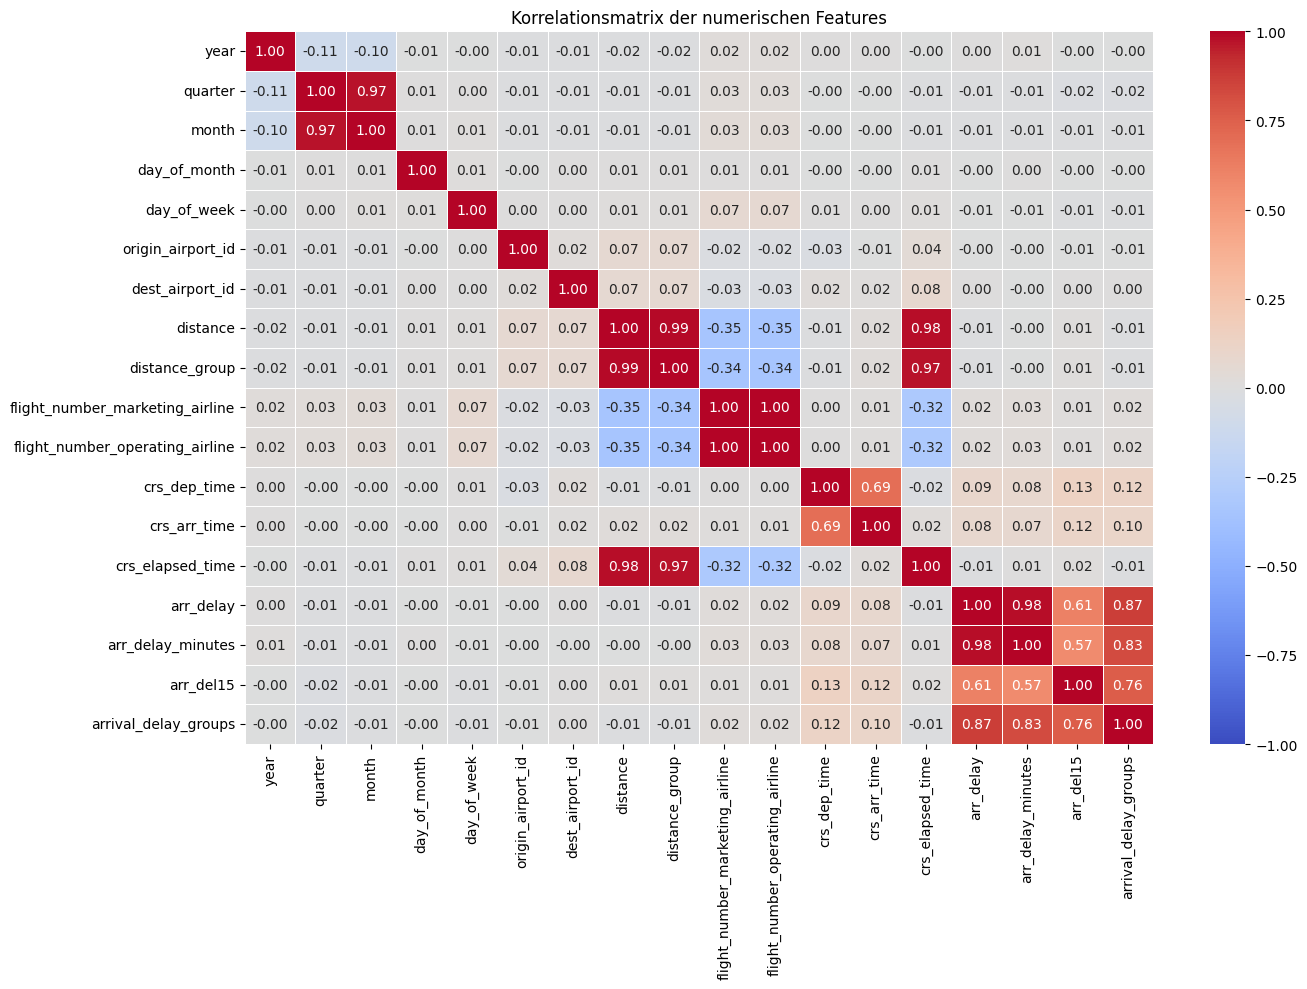

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nur numerische Spalten auswählen
numeric_df = df.select_dtypes(include=['number'])

# Korrelationsmatrix berechnen
corr_matrix = numeric_df.corr()

# Heatmap zeichnen
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Korrelationsmatrix der numerischen Features")
plt.tight_layout()
plt.show()

In [22]:
corr_matrix

,year,quarter,month,day_of_month,day_of_week,origin_airport_id,dest_airport_id,distance,distance_group,flight_number_marketing_airline,flight_number_operating_airline,crs_dep_time,crs_arr_time,crs_elapsed_time,arr_delay,arr_delay_minutes,arr_del15,arrival_delay_groups
year,1.000000,-0.106154,-0.101605,-0.006227,-0.002329,-0.013978,-0.010624,-0.015181,-0.015535,0.017050,0.017066,0.000601,0.002290,-0.003086,0.003776,0.009319,-0.001184,-0.000330
quarter,-0.106154,1.000000,0.971159,0.007732,0.000195,-0.009782,-0.008421,-0.011627,-0.011617,0.030726,0.030766,-0.003226,-0.004933,-0.014592,-0.011947,-0.013010,-0.016706,-0.016103
month,-0.101605,0.971159,1.000000,0.007232,0.011892,-0.009508,-0.008382,-0.011119,-0.011159,0.033976,0.034018,-0.002163,-0.004570,-0.013713,-0.010959,-0.012210,-0.014747,-0.014605
day_of_month,-0.006227,0.007732,0.007232,1.000000,0.009222,-0.000965,0.002321,0.005314,0.005813,0.005337,0.005334,-0.001923,-0.001894,0.006073,-0.000420,0.000795,-0.001899,-0.001464
day_of_week,-0.002329,0.000195,0.011892,0.009222,1.000000,0.003292,0.004953,0.012512,0.012840,0.066100,0.066077,0.005827,0.004487,0.010633,-0.007789,-0.006332,-0.007932,-0.009908
origin_airport_id,-0.013978,-0.009782,-0.009508,-0.000965,0.003292,1.000000,0.021861,0.065968,0.069271,-0.021781,-0.021794,-0.026907,-0.007412,0.043541,-0.004723,-0.004121,-0.005034,-0.005778
dest_airport_id,-0.010624,-0.008421,-0.008382,0.002321,0.004953,0.021861,1.000000,0.065774,0.069040,-0.028830,-0.028824,0.022497,0.015288,0.077478,0.000203,-0.002126,0.004909,0.002851
distance,-0.015181,-0.011627,-0.011119,0.005314,0.012512,0.065968,0.065774,1.000000,0.988078,-0.347638,-0.347627,-0.011323,0.015762,0.982284,-0.014159,-0.000519,0.011320,-0.010172
distance_group,-0.015535,-0.011617,-0.011159,0.005813,0.012840,0.069271,0.069040,0.988078,1.000000,-0.344500,-0.344487,-0.011986,0.018945,0.971636,-0.014173,-0.000507,0.010936,-0.010355
flight_number_marketing_airline,0.017050,0.030726,0.033976,0.005337,0.066100,-0.021781,-0.028830,-0.347638,-0.344500,1.000000,0.999934,0.001364,0.013082,-0.315562,0.022427,0.025152,0.012886,0.020489


In [21]:
target = "arr_delay_minutes"
print(corr_matrix[target].sort_values(ascending=False))

arr_delay_minutes                  1.000000
arr_delay                          0.983222
arrival_delay_groups               0.826301
arr_del15                          0.565393
crs_dep_time                       0.081397
crs_arr_time                       0.074208
flight_number_operating_airline    0.025380
flight_number_marketing_airline    0.025152
year                               0.009319
crs_elapsed_time                   0.005513
day_of_month                       0.000795
distance_group                    -0.000507
distance                          -0.000519
dest_airport_id                   -0.002126
origin_airport_id                 -0.004121
day_of_week                       -0.006332
month                             -0.012210
quarter                           -0.013010
Name: arr_delay_minutes, dtype: float64
